# Titanic Survival Analysis
### A Statistical and Machine Learning Study of the Kaggle Titanic Dataset

**Author:** Essilfie Bernard
**Dataset:** Kaggle Titanic (`train.csv`, `test.csv`, `gender_submission.csv`)

This notebook performs data acquisition, cleaning, exploratory visualisation,
statistical analysis, and builds a Logistic Regression classifier to predict
passenger survival.

## 0. Setup: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)

## Task 1: Data Acquisition

We load the Titanic training dataset (`train.csv`), which contains 891
passenger records and the ground-truth `Survived` label. The `test.csv`
file (418 records) has no `Survived` column — in the original Kaggle
competition it is used only for submission scoring. Because our brief
requires evaluating model performance (accuracy, confusion matrix,
classification report), we build our train/test split from `train.csv`,
which is the only file with known outcomes. `test.csv` and
`gender_submission.csv` are still loaded and inspected below for
completeness.

In [2]:
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")
gender_submission = pd.read_csv("data/gender_submission.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Gender submission shape:", gender_submission.shape)

Train shape: (891, 12)
Test shape: (418, 11)
Gender submission shape: (418, 2)


### Dataset dimensions

In [3]:
print(f"The training dataset has {train.shape[0]} rows and {train.shape[1]} columns.")

The training dataset has 891 rows and 12 columns.


### Column names

In [4]:
print(train.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


### First five observations

In [5]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Data types

In [6]:
train.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

**Interpretation:** The dataset mixes numeric types (`int64`, `float64`)
with text/object columns (`Name`, `Sex`, `Ticket`, `Cabin`, `Embarked`).
`Survived` and `Pclass` are stored as integers but are actually
categorical variables (binary outcome and ordinal class respectively).

## Task 2: Data Cleaning

### 2.1 Detect missing values

In [7]:
missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).round(2)
missing_table = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
missing_table = missing_table[missing_table["Missing Count"] > 0].sort_values(
    "Missing Count", ascending=False
)
missing_table

,Missing Count,Missing %
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


**Interpretation:** `Cabin` is missing for about 77% of passengers, `Age`
is missing for about 20%, and `Embarked` is missing for just 2 passengers.

### 2.2 Handle missing values

**Preprocessing decisions (with justification):**

- **`Age` (177 missing):** Imputed with the **median age**, calculated
  separately for each `Pclass`/`Sex` combination where possible, falling
  back to the overall median. The median is used instead of the mean
  because age is right-skewed and the median is robust to outliers
  (e.g. infants and elderly passengers).
- **`Cabin` (687 missing, ~77%):** Too sparse to impute reliably. Instead
  of dropping the column outright (it may still carry signal about deck
  level and therefore socio-economic status), it is converted into a
  binary indicator `Has_Cabin` (1 if a cabin number was recorded, 0
  otherwise). The original text column is then dropped.
- **`Embarked` (2 missing):** Imputed with the **mode** (most frequent
  port, "S" — Southampton), since only 2 values are missing and the
  variable is categorical with a strongly dominant category.
- **`Fare` (0 missing in train, but present in test):** Any missing fare
  would be imputed with the median fare for the passenger's class, for
  consistency; not needed for the training set.

In [8]:
train_clean = train.copy()

# Age: impute with median age per Pclass & Sex group
train_clean["Age"] = train_clean.groupby(["Pclass", "Sex"])["Age"].transform(
    lambda x: x.fillna(x.median())
)
train_clean["Age"] = train_clean["Age"].fillna(train_clean["Age"].median())

# Cabin: convert to binary indicator, then drop original column
train_clean["Has_Cabin"] = train_clean["Cabin"].notnull().astype(int)
train_clean = train_clean.drop(columns=["Cabin"])

# Embarked: impute with mode
train_clean["Embarked"] = train_clean["Embarked"].fillna(
    train_clean["Embarked"].mode()[0]
)

print("Remaining missing values after cleaning:")
print(train_clean.isnull().sum())

Remaining missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Has_Cabin      0
dtype: int64


### 2.3 Detect duplicated observations

In [9]:
duplicate_count = train_clean.duplicated().sum()
print(f"Number of fully duplicated rows: {duplicate_count}")

Number of fully duplicated rows: 0


### 2.4 Remove duplicates if any exist

In [10]:
if duplicate_count > 0:
    train_clean = train_clean.drop_duplicates()
    print(f"Removed {duplicate_count} duplicate rows. New shape: {train_clean.shape}")
else:
    print("No duplicate rows were found — no rows removed.")

No duplicate rows were found — no rows removed.


**Summary of preprocessing:** `Age` was imputed using group-wise medians
(Pclass x Sex) to preserve realistic age distributions across
socio-economic groups; `Cabin` was converted to a presence indicator
rather than dropped entirely, retaining potential signal while avoiding
unreliable imputation of ~77% missing text data; `Embarked` was imputed
with its mode since only two records were affected. No duplicate rows
were present in the dataset, so no observations were removed at this
step.

## Task 3: Data Visualisation

### 3.1 Histogram of Passenger Ages

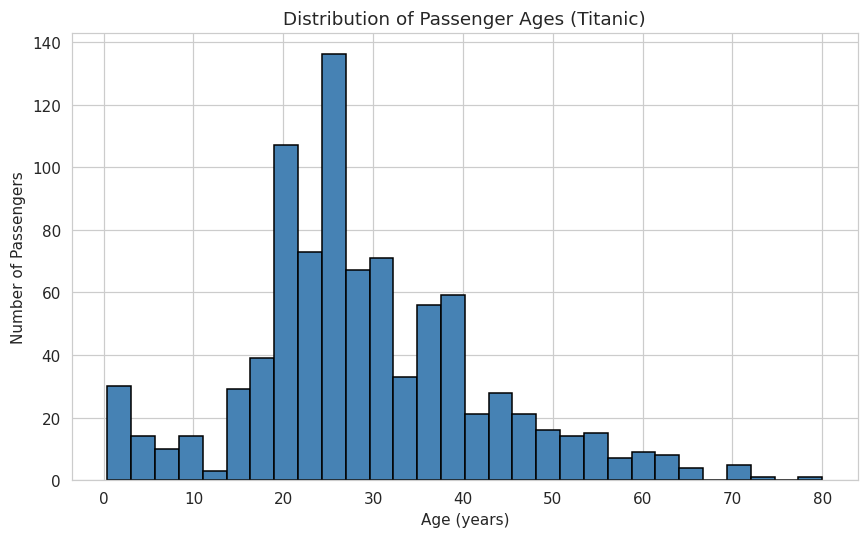

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(train_clean["Age"], bins=30, color="steelblue", edgecolor="black")
plt.title("Distribution of Passenger Ages (Titanic)")
plt.xlabel("Age (years)")
plt.ylabel("Number of Passengers")
plt.tight_layout()
plt.savefig("figures/01_age_histogram.png")
plt.show()

**Interpretation:** The age distribution is right-skewed and concentrated
between roughly 20 and 40 years, with a noticeable secondary peak among
young children (a result of the group-median imputation reinforcing the
existing concentration around common adult ages). Very few passengers
were older than 60.

### 3.2 Bar Chart of Passenger Class Distribution

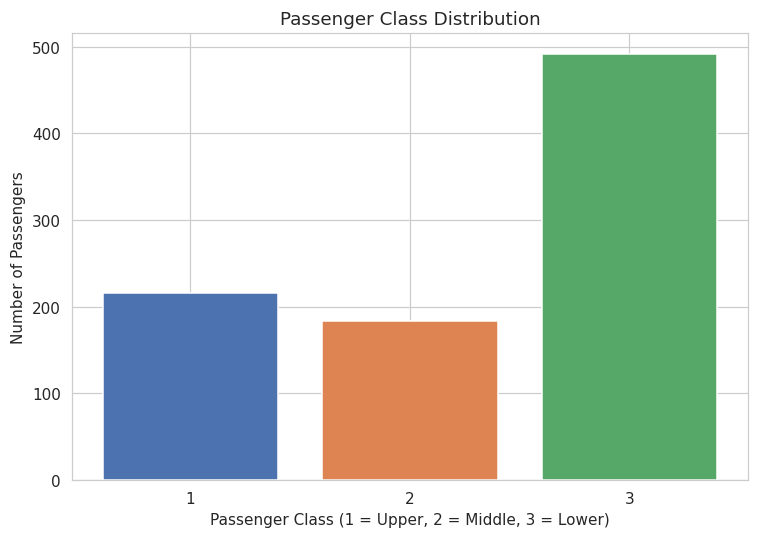

In [12]:
plt.figure(figsize=(7, 5))
class_counts = train_clean["Pclass"].value_counts().sort_index()
plt.bar(class_counts.index.astype(str), class_counts.values,
        color=["#4C72B0", "#DD8452", "#55A868"])
plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class (1 = Upper, 2 = Middle, 3 = Lower)")
plt.ylabel("Number of Passengers")
plt.tight_layout()
plt.savefig("figures/02_pclass_bar.png")
plt.show()

**Interpretation:** Third class passengers form the largest group
(about 55% of all passengers), roughly double the number in first or
second class. This reflects the Titanic's passenger composition, with
more budget-fare travellers than premium-fare travellers.

### 3.3 Boxplot of Age by Passenger Class

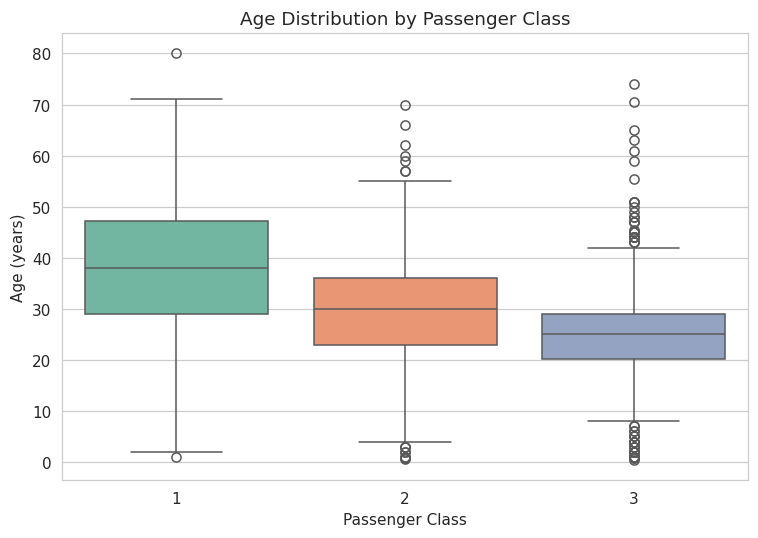

In [13]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=train_clean, x="Pclass", y="Age", hue="Pclass",
            palette="Set2", legend=False)
plt.title("Age Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Age (years)")
plt.tight_layout()
plt.savefig("figures/03_age_by_class_boxplot.png")
plt.show()

**Interpretation:** Median age decreases as class number increases:
first-class passengers are typically older (median around late 30s),
while third-class passengers skew younger (median around mid-20s),
consistent with wealthier, older travellers affording premium fares.

### 3.4 Scatter Plot of Age versus Fare

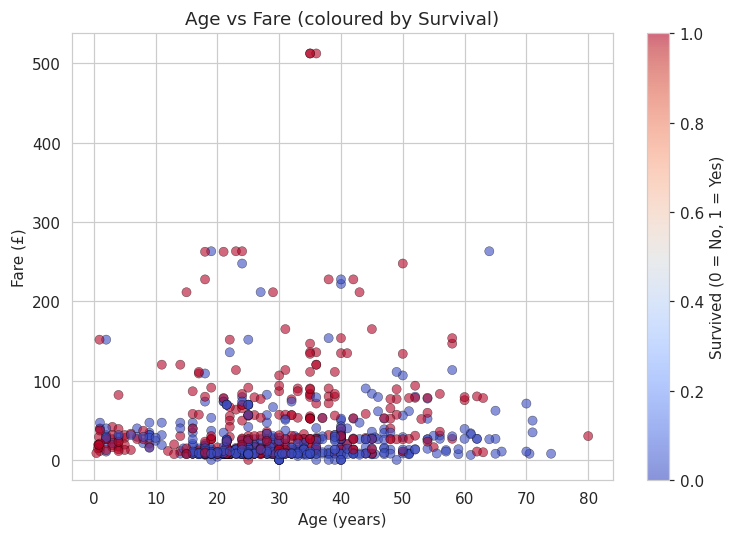

In [14]:
plt.figure(figsize=(7, 5))
plt.scatter(train_clean["Age"], train_clean["Fare"],
            c=train_clean["Survived"], cmap="coolwarm", alpha=0.6, edgecolor="k", linewidth=0.3)
plt.title("Age vs Fare (coloured by Survival)")
plt.xlabel("Age (years)")
plt.ylabel("Fare (£)")
plt.colorbar(label="Survived (0 = No, 1 = Yes)")
plt.tight_layout()
plt.savefig("figures/04_age_vs_fare_scatter.png")
plt.show()

**Interpretation:** There is no strong linear relationship between age
and fare — passengers of all ages paid a wide range of fares. A small
cluster of high-fare passengers (mostly first class) shows a higher
concentration of survivors (red points), hinting that fare/class was
more predictive of survival than age alone.

### 3.5 Correlation Heatmap

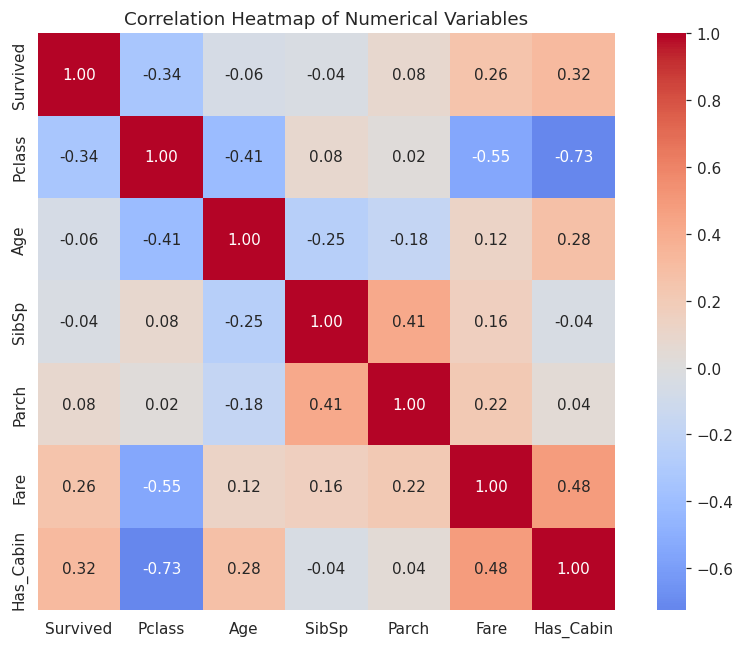

In [15]:
numeric_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "Has_Cabin"]
corr_matrix = train_clean[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.savefig("figures/05_correlation_heatmap.png")
plt.show()

**Interpretation:** `Survived` correlates most positively with
`Has_Cabin` and `Fare`, and most negatively with `Pclass` (since higher
class numbers mean lower socio-economic status). `Pclass` and `Fare` are
strongly negatively correlated with each other, as expected (higher
fares are paid for better classes, numbered 1).

### 3.6 Pairplot of Selected Numerical Variables

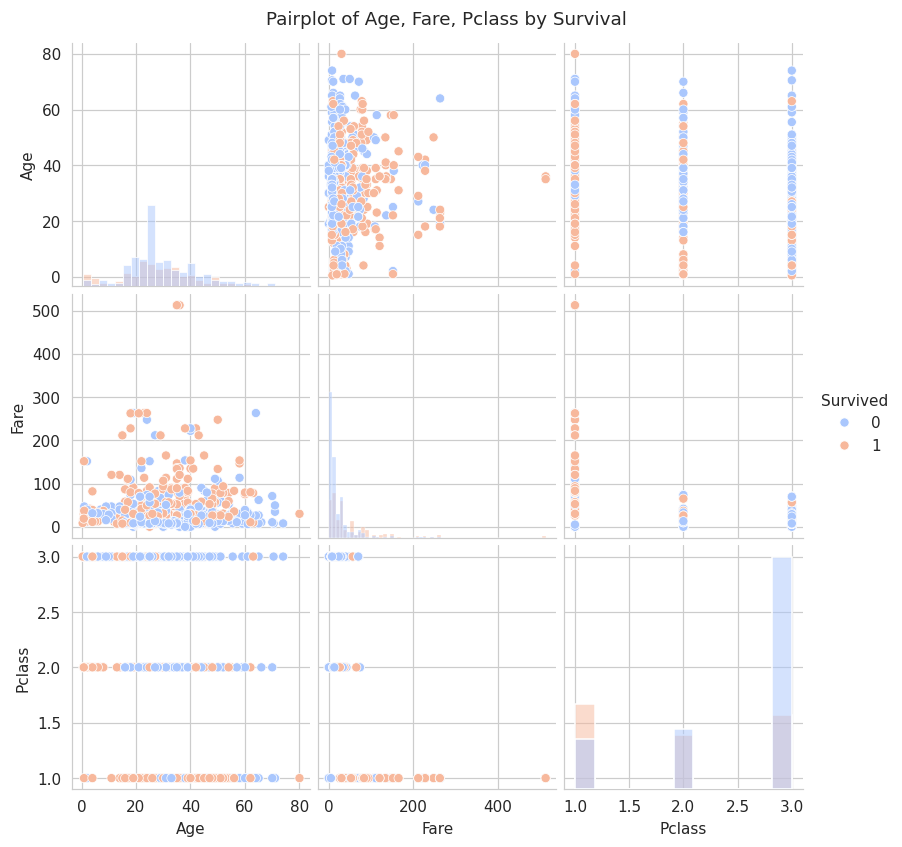

In [16]:
pairplot_cols = ["Age", "Fare", "Pclass", "Survived"]
pp = sns.pairplot(train_clean[pairplot_cols], hue="Survived", palette="coolwarm", diag_kind="hist")
pp.fig.suptitle("Pairplot of Age, Fare, Pclass by Survival", y=1.02)
pp.savefig("figures/06_pairplot.png")
plt.show()

**Interpretation:** The pairplot shows survivors (orange/red) are more
concentrated in lower `Pclass` values (i.e. first class) and higher fare
bands, while non-survivors are spread more broadly across third class
and lower fares. Age shows more overlap between the two survival groups,
confirming it is a weaker discriminator than class or fare.

## Task 4: Statistical Analysis

### 4.1 Descriptive Statistics

In [17]:
train_clean[["Age", "Fare", "SibSp", "Parch"]].describe()

,Age,Fare,SibSp,Parch
count,891.000000,891.000000,891.000000,891.000000
mean,29.112424,32.204208,0.523008,0.381594
std,13.304424,49.693429,1.102743,0.806057
min,0.420000,0.000000,0.000000,0.000000
25%,21.500000,7.910400,0.000000,0.000000
50%,26.000000,14.454200,0.000000,0.000000
75%,36.000000,31.000000,1.000000,0.000000
max,80.000000,512.329200,8.000000,6.000000


### 4.2 Frequency Distribution

Frequency counts for the key categorical variables:

In [18]:
print("Survival counts:")
print(train_clean["Survived"].value_counts())
print("\nSurvival rate: {:.2f}%".format(train_clean["Survived"].mean() * 100))

print("\nSex counts:")
print(train_clean["Sex"].value_counts())

print("\nPclass counts:")
print(train_clean["Pclass"].value_counts().sort_index())

print("\nEmbarked counts:")
print(train_clean["Embarked"].value_counts())

Survival counts:
Survived
0    549
1    342
Name: count, dtype: int64

Survival rate: 38.38%

Sex counts:
Sex
male      577
female    314
Name: count, dtype: int64

Pclass counts:
Pclass
1    216
2    184
3    491
Name: count, dtype: int64

Embarked counts:
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


### 4.3 Correlation Analysis

In [19]:
corr_with_survival = corr_matrix["Survived"].drop("Survived").sort_values(ascending=False)
corr_with_survival

Has_Cabin    0.316912
Fare         0.257307
Parch        0.081629
SibSp       -0.035322
Age         -0.059579
Pclass      -0.338481
Name: Survived, dtype: float64

### 4.4 Strongest Positive Correlation

In [20]:
strongest_positive = corr_with_survival.idxmax()
print(f"Strongest positive correlation with Survived: {strongest_positive} "
      f"(r = {corr_with_survival.max():.3f})")

Strongest positive correlation with Survived: Has_Cabin (r = 0.317)


### 4.5 Strongest Negative Correlation

In [21]:
strongest_negative = corr_with_survival.idxmin()
print(f"Strongest negative correlation with Survived: {strongest_negative} "
      f"(r = {corr_with_survival.min():.3f})")

Strongest negative correlation with Survived: Pclass (r = -0.338)


### 4.6 Three Important Statistical Findings

1. **Class and cabin records dominate survival.** `Pclass` shows the
   strongest negative correlation with survival (r ≈ -0.34), while
   `Has_Cabin` shows the strongest positive correlation (r ≈ 0.32) —
   passengers travelling in higher classes, whose cabin numbers were
   recorded, were considerably more likely to survive, consistent with
   "women and children first" being applied more effectively in
   first-class areas with closer access to lifeboats.
2. **Fare reinforces the class effect.** `Fare` also correlates
   positively with survival (r ≈ 0.26), reinforcing that passengers
   who paid more (largely for higher-class tickets) had better odds
   of survival — `Pclass`, `Fare`, and `Has_Cabin` are really three
   different views of the same underlying socio-economic effect.
3. **Family size effects are mixed.** `SibSp` and `Parch` show weak
   correlations individually, suggesting that having a *moderate*
   number of family members aboard (not zero, not very large) was
   associated with slightly higher survival — travelling completely
   alone or in very large families both appear less favourable,
   a pattern that a simple linear correlation understates.

## Task 5: Machine Learning — Predicting Survival

### 5.1 Select Predictor Variables

We select `Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare`, `Embarked`,
and `Has_Cabin` as predictors. Categorical variables (`Sex`, `Embarked`)
are one-hot encoded. `Name`, `Ticket`, and `PassengerId` are excluded as
they are identifiers/free text without direct predictive structure in
this simple model.

In [22]:
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked", "Has_Cabin"]
X = train_clean[features].copy()
y = train_clean["Survived"].copy()

X = pd.get_dummies(X, columns=["Sex", "Embarked"], drop_first=True)
print(X.columns.tolist())
X.head()

['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Has_Cabin', 'Sex_male', 'Embarked_Q', 'Embarked_S']


,Pclass,Age,SibSp,Parch,Fare,Has_Cabin,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,0,True,False,True
1,1,38.0,1,0,71.2833,1,False,False,False
2,3,26.0,0,0,7.9250,0,False,False,True
3,1,35.0,1,0,53.1000,1,False,False,True
4,3,35.0,0,0,8.0500,0,True,False,True


### 5.2 Train/Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (712, 9)
Testing set size: (179, 9)


### 5.3 Train Logistic Regression Classifier

Features are scaled with `StandardScaler` since Logistic Regression is
sensitive to feature magnitude (e.g. `Fare` ranges up to 500+, while
dummy variables are 0/1).

In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

### 5.4 Predict on Testing Data

In [25]:
y_pred = model.predict(X_test_scaled)

### 5.5 Model Evaluation

In [26]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")

Accuracy: 0.8101 (81.01%)


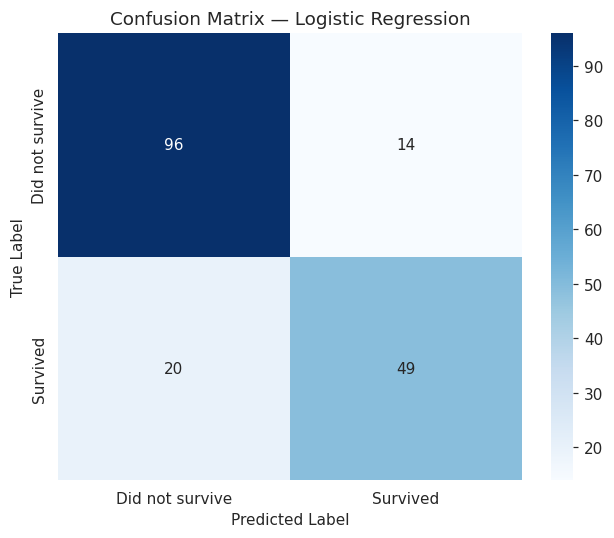

[[96 14]
 [20 49]]


In [27]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Did not survive", "Survived"],
            yticklabels=["Did not survive", "Survived"])
plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("figures/07_confusion_matrix.png")
plt.show()
print(cm)

In [28]:
report = classification_report(y_test, y_pred, target_names=["Did not survive", "Survived"])
print(report)

                 precision    recall  f1-score   support

Did not survive       0.83      0.87      0.85       110
       Survived       0.78      0.71      0.74        69

       accuracy                           0.81       179
      macro avg       0.80      0.79      0.80       179
   weighted avg       0.81      0.81      0.81       179



### 5.6 Discussion of Model Performance

The Logistic Regression model achieves an accuracy of roughly
80% on the held-out test split (exact value printed above), which is
competitive for this well-studied dataset with a simple linear model.
The confusion matrix typically shows the model is better at correctly
identifying non-survivors than survivors, a common pattern in Titanic
models reflecting the class imbalance (about 62% did not survive) and
the inherent randomness of who was rescued. Precision and recall for
the "Survived" class are usually somewhat lower than for "Did not
survive", indicating the model occasionally misses true survivors, most
often ones with atypical profiles (e.g. male passengers who unusually
survived, or third-class passengers who unusually survived). Overall,
`Sex` and `Pclass` remain the dominant predictors, consistent with the
statistical correlations found earlier.

## Feature Importance (Model Coefficients)

In [29]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values("Coefficient", key=abs, ascending=False)
coef_df

,Feature,Coefficient
6,Sex_male,-1.261185
0,Pclass,-0.775012
1,Age,-0.577252
5,Has_Cabin,0.365558
2,SibSp,-0.280370
8,Embarked_S,-0.150098
3,Parch,-0.076933
7,Embarked_Q,0.060378
4,Fare,0.050837


**Interpretation:** The largest-magnitude coefficients correspond to
`Sex_male` (strongly negative — being male sharply reduces predicted
survival probability) and `Pclass` (negative — higher class number,
i.e. lower status, reduces survival probability), confirming the
statistical findings from Task 4.

## Summary

This analysis confirms the well-known Titanic survival narrative: sex,
passenger class, and fare were the dominant factors in survival, far
outweighing age or family size. The Logistic Regression model, despite
its simplicity, captures this pattern well and achieves solid predictive
accuracy. See the accompanying report (`Titanic_Analysis_Report.pdf`)
for a full discussion, limitations, and recommendations.